In [1]:
import platform
platform.platform()

'macOS-15.6.1-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np
np.__version__

'1.23.5'

In [7]:
import pandas as pd
pd.__version__

'2.3.3'

In [8]:
from rdkit import rdBase
rdBase.rdkitVersion

'2023.09.1'

In [9]:
import scipy
scipy.__version__

'1.15.3'

In [10]:
from SSMetrics import ecfp, shannon_entropy

In [11]:
df1 = pd.read_csv("../../1_dataset/1_28descriptors/1_dataset/2_standardization/standardized_dataset.csv")
df1.shape

(4665, 37)

In [12]:
df1.columns

Index(['SMILES', 'InChI', 'InChIKey', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl',
       'Diacetyl', 'T(p-OMe)PPCo', 'Electrode', 'm_1_L', 'm_1_B1', 'm_1_B5',
       'p_L', 'p_B1', 'p_B5', 'm_2_L', 'm_2_B1', 'm_2_B5', 'o_L', 'o_B1',
       'o_B5', 'Charge_O', 'Charge_next_O', 'Charge_o_1', 'Charge_m_1',
       'Charge_p', 'Charge_m_2', 'Charge_o_2', 'HOMO', 'MolLogP', 'MolWt',
       'num_N', 'num_O', 'num_S', 'num_F', 'num_Cl', 'num_Br'],
      dtype='object')

In [13]:
df2 = ecfp(df1["InChI"])
df2.shape

(4665, 2048)

In [14]:
df2.columns

RangeIndex(start=0, stop=2048, step=1)

In [15]:
entropies = []

m_1_L:	0.520307128377752 ± 8.22715434302735e-09 bit
m_1_B1:	0.5398615053825399 ± 1.3295878848951258e-08 bit
m_1_B5:	0.5098648439495405 ± 1.033206525068281e-08 bit
p_L:	1.5594185650145402 ± 7.800392393842722e-09 bit
p_B1:	1.5548815861174252 ± 1.0806251917635507e-08 bit
p_B5:	1.5533585889610548 ± 1.566017844635826e-08 bit
m_2_L:	0.5412349355746219 ± 1.1517884155634764e-08 bit
m_2_B1:	0.5383088969434933 ± 7.291303532786546e-09 bit
m_2_B5:	0.5098137838740381 ± 4.729896712085058e-09 bit
o_L:	1.6013336813719923 ± 3.860853599771622e-12 bit
o_B1:	1.6805630583175843 ± 2.1544728150550754e-08 bit
o_B5:	1.6993785084727053 ± 6.215121599486009e-09 bit
Charge_O:	1.9571094693135906 ± 2.805188705426598e-08 bit
Charge_next_O:	2.0441445907968148 ± 1.7003029842382944e-08 bit
Charge_o_1:	1.6320194105929504 ± 1.206647149072082e-08 bit
Charge_m_1:	0.797862300077687 ± 1.1544462403638611e-08 bit
Charge_p:	1.6445849831713957 ± 1.776807912383756e-08 bit
Charge_m_2:	1.1690637848616388 ± 9.252924429112237e-09 bit


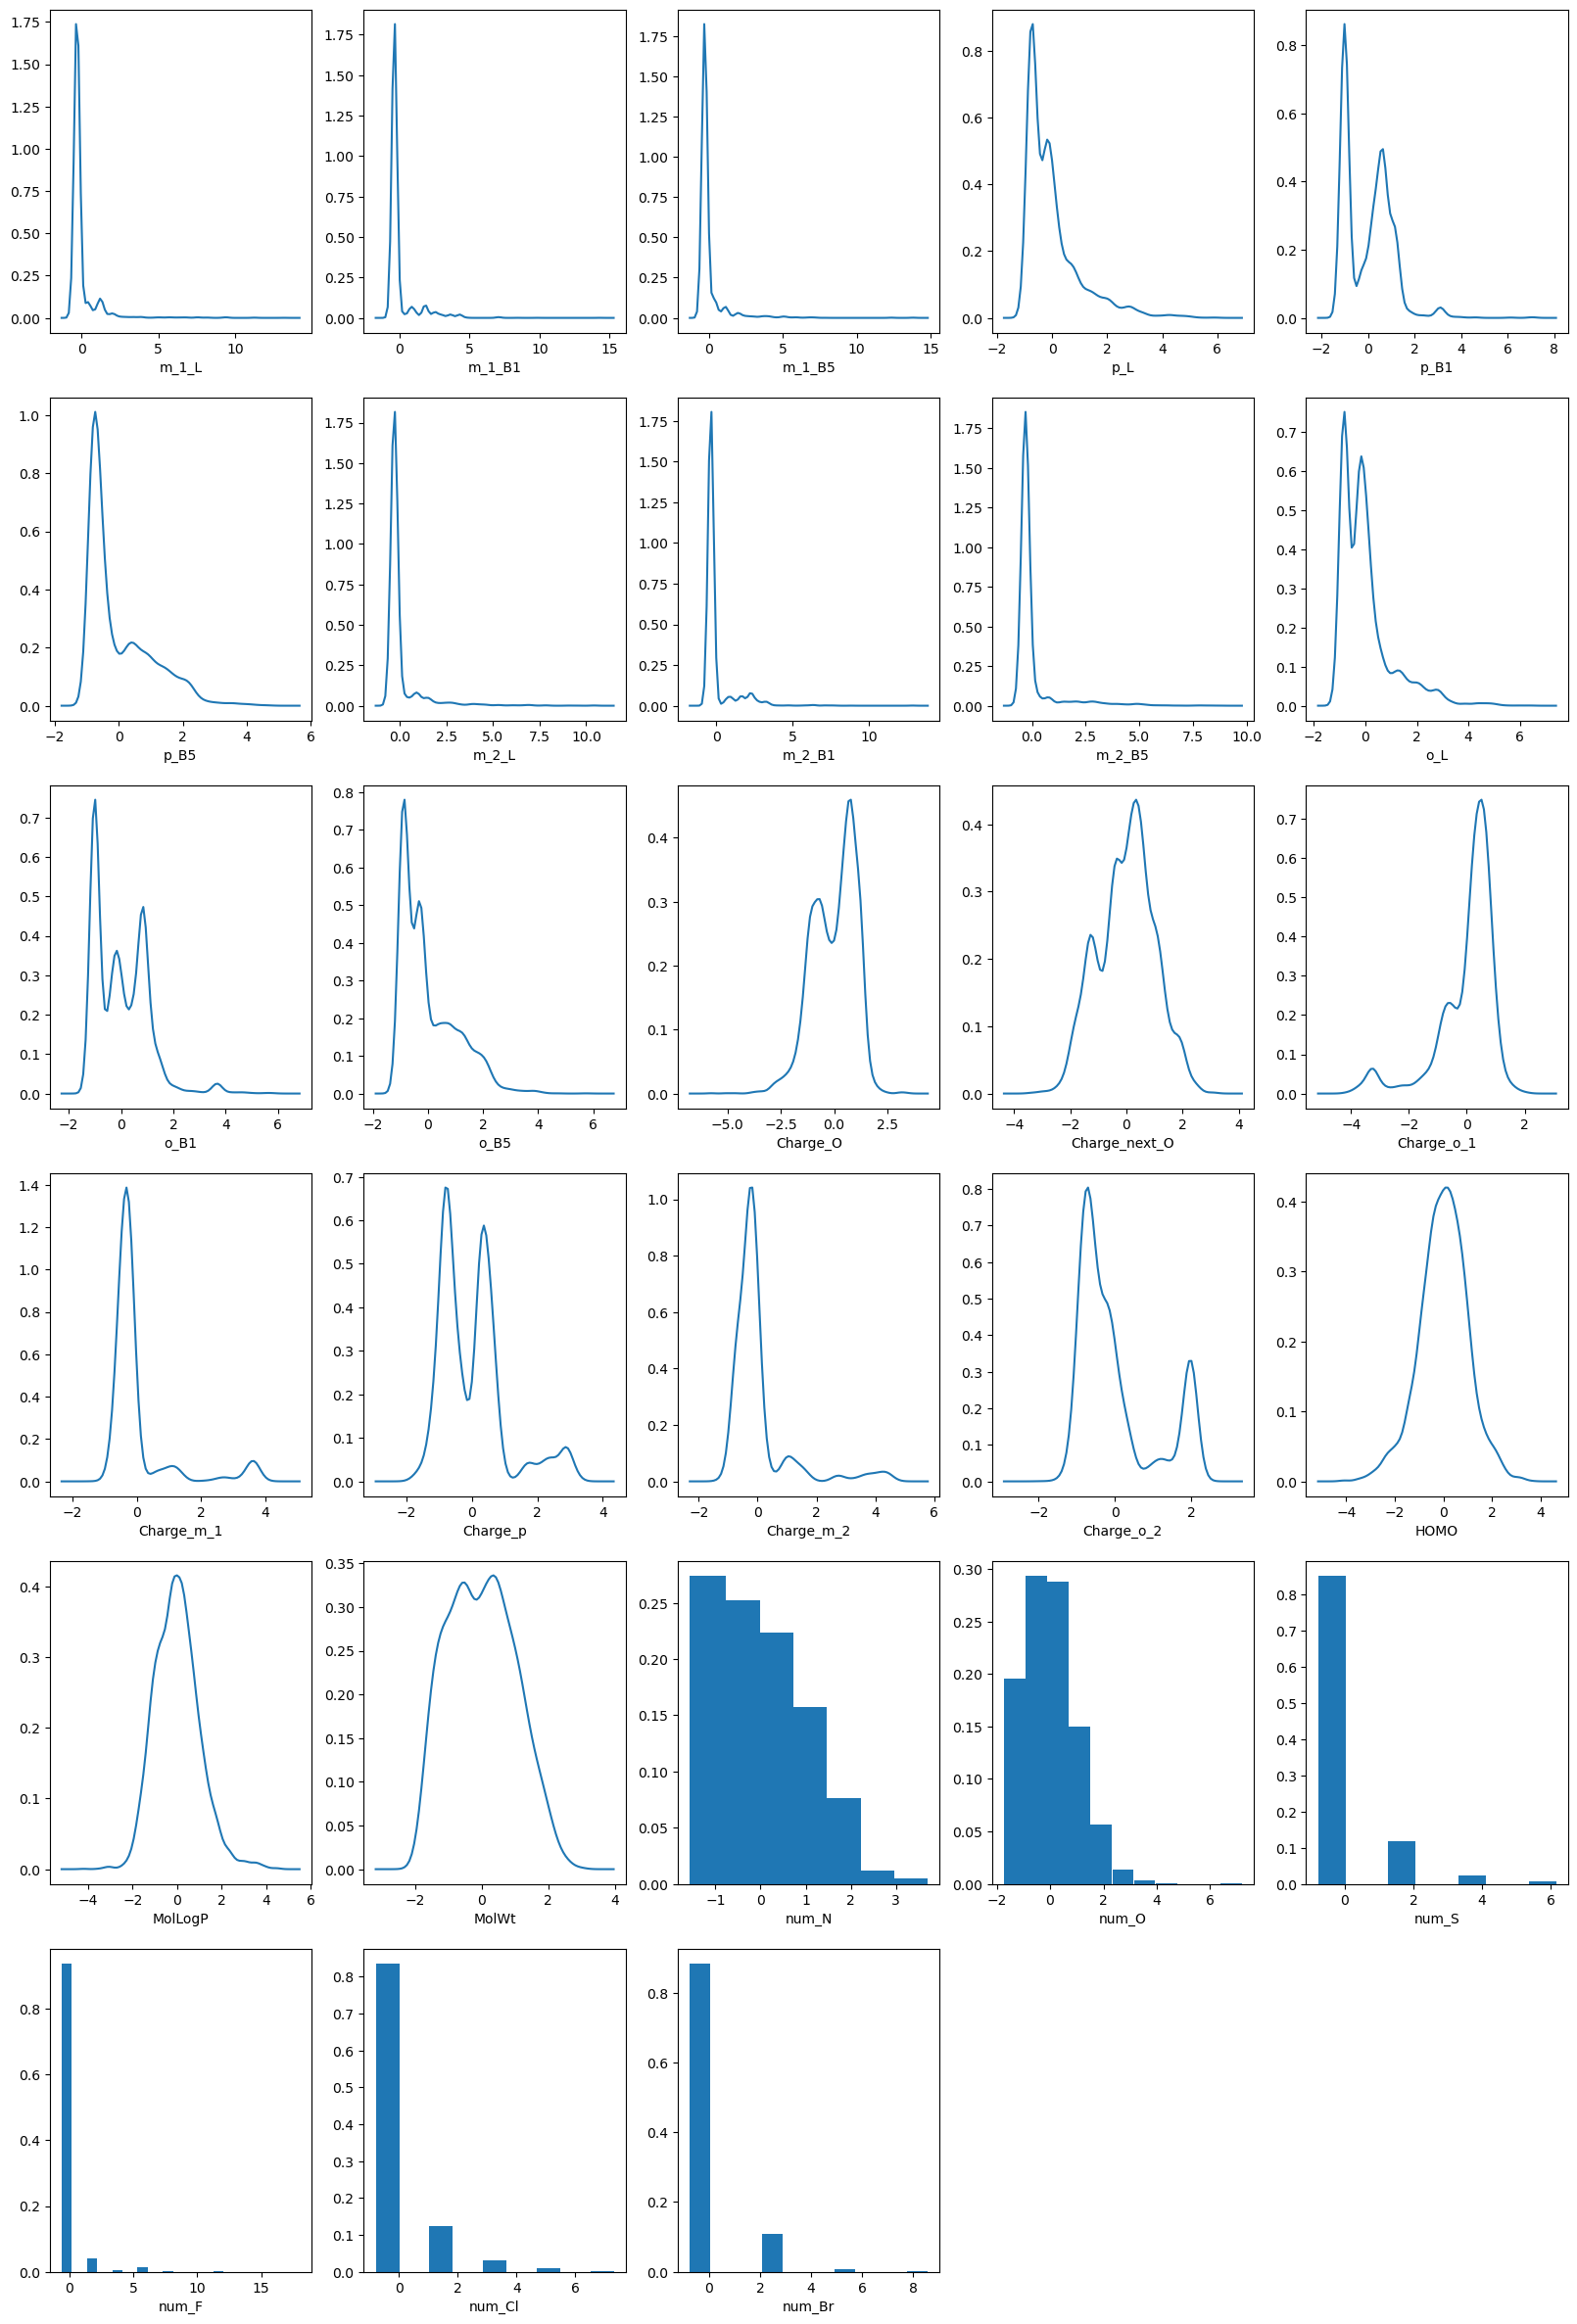

In [16]:
entropy_28d = shannon_entropy.sum_entropy_28d(df1,
                                              "probability_distribution.png")
entropies.append(entropy_28d[0])

In [17]:
entropy_ecfp = shannon_entropy.sum_entropy_bits(df2, 2048)
entropies.append(entropy_ecfp[0])

Sum of Entropy:	9.904068235792632 bit


In [18]:
df_result = pd.DataFrame({"Descriptor": ["28 Descriptors",
                                         "ECFP"],
                          "Entropy": entropies})
df_result

,Descriptor,Entropy
0,28 Descriptors,36.703896
1,ECFP,9.904068


In [19]:
df_result.to_csv("shannon_entropy.csv", index=False)

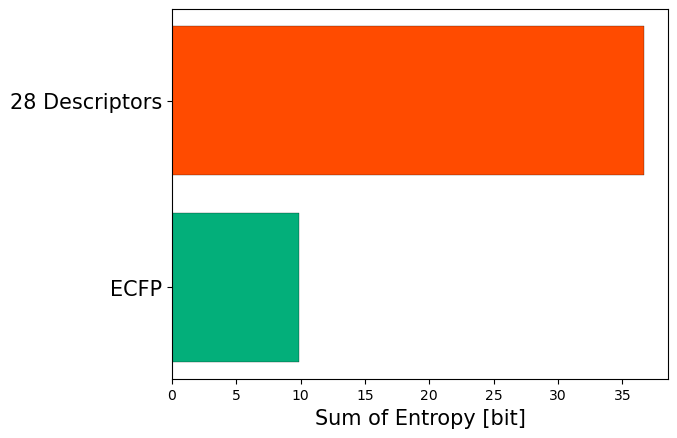

In [20]:
fig = plt.figure()
ax = fig.add_subplot()

y = df_result["Descriptor"][::-1]
x = df_result["Entropy"][::-1]

colours = [(255/255, 75/255, 0/255),
           (3/255, 175/255, 122/255)][::-1]

ax.barh(y, x, color=colours, edgecolor="k", linewidth=0.2)
ax.set_xlabel("Sum of Entropy [bit]", fontsize=15)

plt.yticks(fontsize=15)

plt.savefig("shannon_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
orange1 = (246/255, 170/255, 0/255, 0.2)
orange2 = (246/255, 170/255, 0/255, 0.6)
orange3 = (246/255, 170/255, 0/255)

green1 = (3/255, 175/255, 122/255, 0.2)
green2 = (3/255, 175/255, 122/255, 0.6)
green3 = (3/255, 175/255, 122/255)

purple1 = (153/255, 0/255, 153/255, 0.2)
purple2 = (153/255, 0/255, 153/255, 0.6)
purple3 = (153/255, 0/255, 153/255)

sky1 = (77/255, 196/255, 255/255, 0.2)
sky2 = (77/255, 196/255, 255/255, 0.6)
sky3 = (77/255, 196/255, 255/255)

red1 = (255/255, 75/255, 0/255, 0.1)
red2 = (255/255, 75/255, 0/255, 0.25)
red3 = (255/255, 75/255, 0/255, 0.4)
red4 = (255/255, 75/255, 0/255, 0.55)
red5 = (255/255, 75/255, 0/255, 0.7)
red6 = (255/255, 75/255, 0/255, 0.85)
red7 = (255/255, 75/255, 0/255)

blue1 = (0/255, 90/255, 255/255, 0.2)
blue2 = (0/255, 90/255, 255/255, 0.6)
blue3 = (0/255, 90/255, 255/255)

pink1 = (255/255, 128/255, 130/255, 0.2)
pink2 = (255/255, 128/255, 130/255, 0.6)
pink3 = (255/255, 128/255, 130/255)

brown1 = (128/255, 64/255, 0/255, 0.2)
brown2 = (128/255, 64/255, 0/255, 0.6)
brown3 = (128/255, 64/255, 0/255)

colours = [orange1, orange2, orange3,
           green1, green2, green3,
           purple1, purple2, purple3,
           sky1, sky2, sky3,
           red1, red2, red3, red4, red5, red6, red7,
           blue1, blue2, blue3,
           pink1, pink2, pink3, brown1, brown2, brown3]
len(colours)

28

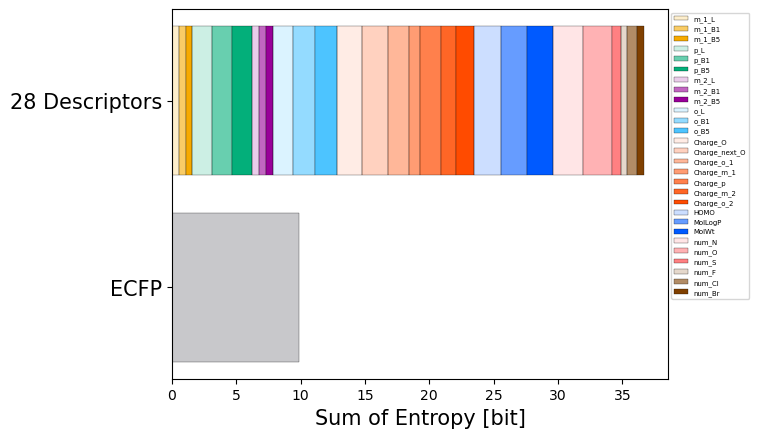

In [22]:
fig = plt.figure()
ax = fig.add_subplot()

ax.barh(df_result["Descriptor"][1],
        df_result["Entropy"][1],
        color=(200/255, 200/255, 203/255), edgecolor="k", linewidth=0.2)

left = 0
for i in range(28):
    ax.barh(df_result["Descriptor"][0],
            entropy_28d[1][i],
            left=left,
            label=df1.columns[9:37][i],
            color=colours[i], edgecolor="k", linewidth=0.2)
    left += entropy_28d[1][i]

ax.legend(loc="upper left", fontsize=5, bbox_to_anchor=(1, 1))
ax.set_xlabel("Sum of Entropy [bit]", fontsize=15)

plt.yticks(fontsize=15)

plt.savefig("shannon_entropy_details.png", dpi=300, bbox_inches="tight")
plt.show()